In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from pathlib import Path

In [2]:
BASE_DIR = Path.cwd().parent.parent
PROC_PATH = BASE_DIR / "data" / "processed"
ASSETS_PATH = BASE_DIR / "src" / "visualization"

df = pd.read_csv(PROC_PATH / "datos_procesados_visual.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Unnamed: 0                1470 non-null   int64
 1   Age                       1470 non-null   int64
 2   Target                    1470 non-null   str  
 3   BusinessTravel            1470 non-null   str  
 4   DailyRate                 1470 non-null   int64
 5   Department                1470 non-null   str  
 6   DistanceFromHome          1470 non-null   int64
 7   Education                 1470 non-null   str  
 8   EducationField            1470 non-null   str  
 9   EmployeeCount             1470 non-null   int64
 10  EmployeeNumber            1470 non-null   int64
 11  EnvironmentSatisfaction   1470 non-null   str  
 12  Gender                    1470 non-null   str  
 13  HourlyRate                1470 non-null   int64
 14  JobInvolvement            1470 non-null   str  
 15

Elimino columnas que no utilizare y que no ayudan al modelo.

In [3]:
df["BusinessTravel"].unique()

<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

In [4]:
df["Department"].unique() #transformar con one encoder

<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

In [5]:
df["Education"].unique()#transformar con one encoder


<StringArray>
['College', 'Below College', 'Master', 'Bachelor', 'Doctor']
Length: 5, dtype: str

In [6]:
df["EducationField"].unique()#transformar con one encoder

<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

In [7]:
df["JobInvolvement"].unique()


<StringArray>
['High', 'Medium', 'Very High', 'Low']
Length: 4, dtype: str

In [8]:
df_model = df.drop(columns=["Unnamed: 0","Age","DistanceFromHome","EmployeeNumber","EmployeeCount", "StandardHours", "Over18"])

In [9]:

columnas_one = ["BusinessTravel","Department","Education","EducationField","JobInvolvement"]

df_model = pd.get_dummies(df_model, columns=columnas_one, drop_first=True)
categorical_columns = df_model.select_dtypes(include = ['str']).columns
    
le = LabelEncoder()
    
for col in categorical_columns:
    df_model[col] = le.fit_transform(df_model[col])

    
print(df_model.info())

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 42 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Target                             1470 non-null   int64
 1   DailyRate                          1470 non-null   int64
 2   EnvironmentSatisfaction            1470 non-null   int64
 3   Gender                             1470 non-null   int64
 4   HourlyRate                         1470 non-null   int64
 5   JobLevel                           1470 non-null   int64
 6   JobRole                            1470 non-null   int64
 7   JobSatisfaction                    1470 non-null   int64
 8   MaritalStatus                      1470 non-null   int64
 9   MonthlyIncome                      1470 non-null   int64
 10  MonthlyRate                        1470 non-null   int64
 11  NumCompaniesWorked                 1470 non-null   int64
 12  OverTime                       

In [10]:
df_model = df_model.astype(int)
print(df_model.info())

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 42 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Target                             1470 non-null   int64
 1   DailyRate                          1470 non-null   int64
 2   EnvironmentSatisfaction            1470 non-null   int64
 3   Gender                             1470 non-null   int64
 4   HourlyRate                         1470 non-null   int64
 5   JobLevel                           1470 non-null   int64
 6   JobRole                            1470 non-null   int64
 7   JobSatisfaction                    1470 non-null   int64
 8   MaritalStatus                      1470 non-null   int64
 9   MonthlyIncome                      1470 non-null   int64
 10  MonthlyRate                        1470 non-null   int64
 11  NumCompaniesWorked                 1470 non-null   int64
 12  OverTime                       

### CREACION DEL MODELO DE MACHINE LEARNING

In [11]:
y = df_model["Target"]
X = df_model.drop("Target", axis=1)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

In [13]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)

In [14]:
model.fit(X_train,y_train)

predictions = model.predict(X_test)

In [15]:
print("----Matriz de Confusión----")
print(confusion_matrix(y_test, predictions))

print("---- Reporte de Clasificación ----")
print(classification_report(y_test, predictions))

----Matriz de Confusión----
[[254   1]
 [ 35   4]]
---- Reporte de Clasificación ----
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



Tenemos un accuracy de un 0.88 sin embargo, los datos estan desbalanceados. En la empresa hay muchisima gente que se queda, entonces el modelo para que no equivocarse aumenta los casos que dice que si se quedan asi acierta mas. 
Tenemos 254 (Verdades Negativos), es decir, casi todos lo que se quedaban, el modeo les acerto. Es muy bueno prediciendo la estabilidad.
4 (verdaderos positivos): de las 39 personas que realmente renunciaron, el modelo solo acerto en 4.
35 (falsos negativos): el modelo dijo que esos empleados se quedaban pero en realidad se fueron.

El recall es solo del 0.10 

Para intentar mejorar los datos, aumentaremos el umbral de las predicciones a un 30%.

In [16]:
#obtenemos las probabilidades de que se vayan (columna 1)
probs = model.predict_proba(X_test)[:,1]

#si la probabilidad es mayo del 30%, decimos que se va (1), sino (0)

predictions_custom = (probs > 0.3).astype(int)

print(classification_report(y_test,predictions_custom))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       255
           1       0.39      0.23      0.29        39

    accuracy                           0.85       294
   macro avg       0.64      0.59      0.60       294
weighted avg       0.82      0.85      0.83       294



Logramos aumentar el recall a un 0.23 por lo que duplicamos la capacidad del modelo para detectar los que se van, sin embargo sigue siendo bajo. 
Probamos el SMOTE, que sirve para crear empleados ficticios para poder igualar la cantidad de empleados que si se van con los que no, y asi el modelo entrena mucho mejor. 

In [17]:
#creo el aumentador de datos
smote = SMOTE(random_state=42)

In [18]:
#genero nuevos datos solo para el entrenamiento
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [19]:
#entreno el modelo con los datos balancedados
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_res, y_train_res)

# 4. Evaluamos con el X_test original (el examen real no se toca)
predictions_smote = model_smote.predict(X_test)

In [20]:
print(classification_report(y_test,predictions_smote))

              precision    recall  f1-score   support

           0       0.90      0.96      0.93       255
           1       0.52      0.28      0.37        39

    accuracy                           0.87       294
   macro avg       0.71      0.62      0.65       294
weighted avg       0.85      0.87      0.85       294



Aumento el recall de un 0.10 a un 0.28 pero lo mejor es que la precision del modelo aumento a un 0.52, esto quiere decir que si el modelo dice este empleado se va, tiene mas de un 0.50 de acierto.

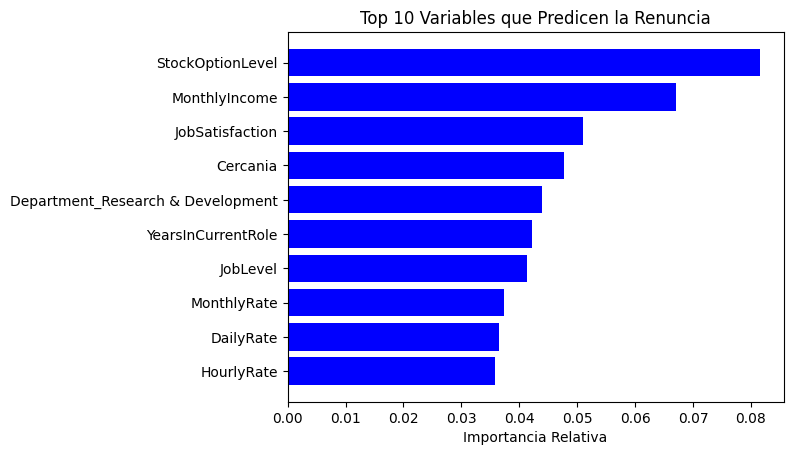

In [22]:
importancias = model_smote.feature_importances_
columnas = X.columns

indices = np.argsort(importancias)[-10:]


plt.title("Top 10 Variables que Predicen la Renuncia")
plt.barh(range(len(indices)), importancias[indices], color='b', align="center")
plt.yticks(range(len(indices)), [columnas[i] for i in indices])
plt.xlabel("Importancia Relativa")
plt.savefig(ASSETS_PATH / "Top_10_variables_renuncias.png")
plt.show()
plt.close()

Estas son las variables que el modelo de predicción nos dice que son las causantes principales de que el empleado se vaya de la empresa.  

Los motivos principales de la renuncias de nuestros empleados se deben a un tema de recompensas y satisfacción principalmente.

### CSV para POWER BI

In [25]:
riesgo_real = model_smote.predict_proba(X)[:,1]

df['probabilidad_abandono'] = riesgo_real

df["Alerta_Riesgo"] = df["probabilidad_abandono"].apply(lambda x:"Alto" if x > 0.70 else ('Medio' if x > 0.3 else "Bajo"))

df.to_csv(PROC_PATH / "Resultado_Final_RRHH.csv", index=False)